In [12]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

LOADING & PREPROCESSING

In [13]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
print('Dataset Shape:', data.shape)
print(data.head())


Dataset Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [14]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [15]:
print(data.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [16]:
print(data.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


Clustering Algorthim

1. KMeans clusterring




Kmeans clustering works
1. Initialization: Choose the value of K (number of clusters) and randomly select K starting points, known as centroids.
2. Assignment: For every data point in the dataset, calculate its distance (usually Euclidean distance) to each of the K centroids. Assign the data point to the cluster whose centroid is the closest.
3. Update Centroids: Once all points are assigned, calculate the new "center" for each cluster by taking the average (mean) of all the data points in that group. Move the centroid to this new location.
4. Repeat: Repeat the Assignment and Update steps until the centroids stop moving or stay in the same position.
5. Final Result: The algorithm outputs the final grouped clusters.

Suitability for the Iris dataset

The Iris dataset is relatively small, has well-defined numerical features, and we generally know there are 3 species (clusters), making it an ideal candidate for distance-based partitioning.
* Numerical Features: KMeans relies on distance calculations (like Euclidean distance), and since the Iris dataset consists entirely of physical measurements (cm), it works perfectly.
* Clear Structure: The Iris species are naturally distinct in size, which fits the "spherical" cluster shape that KMeans looks for.
  

In [17]:
kmeans = KMeans(n_clusters=3,init= 'k-means++',max_iter=300,random_state=42)
y_kmeans = kmeans.fit_predict(data)
data_kmeans = data.copy()
data_kmeans['cluster'] = y_kmeans
print(data_kmeans['cluster'].value_counts())

cluster
2    61
1    50
0    39
Name: count, dtype: int64


C:\Users\chikk\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


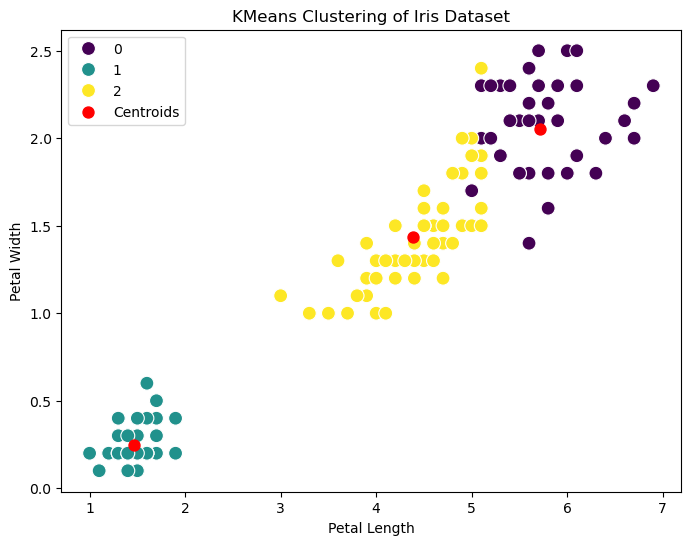

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_kmeans.iloc[:, 2], y=data_kmeans.iloc[:, 3],
                hue=data_kmeans['cluster'], palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], 
            s=250, c='red', marker='.', label='Centroids')
plt.title('KMeans Clustering of Iris Dataset')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

2. Hierarchical Clustering

Description of Hierarchical Clustering

Hierarchical clustering is an unsupervised method that groups data into a tree-like structure.
* The Process: In the "Agglomerative" approach, every data point starts as its own individual cluster. The algorithm then repeatedly merges the two closest clusters until only one large cluster remains.
* The Dendrogram: This is a visual tree used to see how these merges happened. The vertical height of the lines represents the distance between clusters; the taller the line, the more different the clusters are



Suitable for Iris dtaset

* Relationship Discovery: It allows us to see not just the final groups, but also how similar specific flowers are to each other (like a family tree).
* Dataset Size: Because we only have 150 samples, building the full hierarchy is computationally fast and produces a clean, readable dendrogram.
  

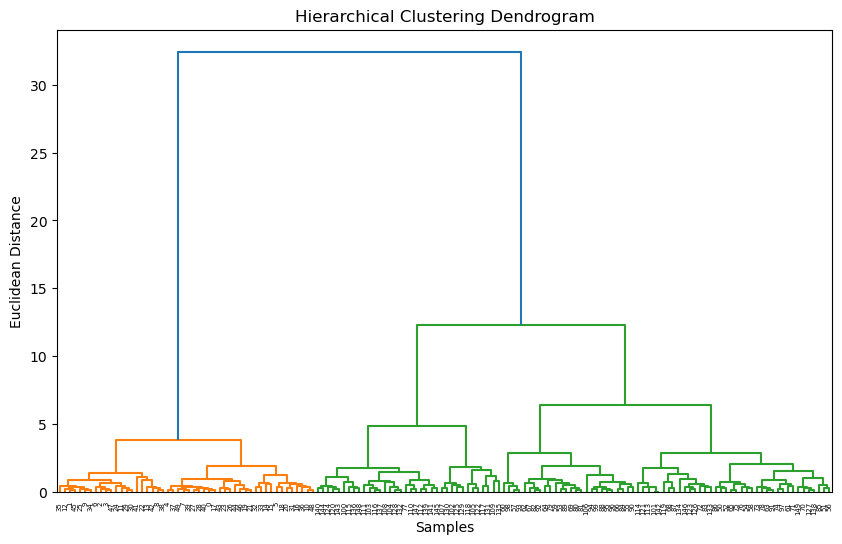

In [19]:
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(data, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()

In [20]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(data)

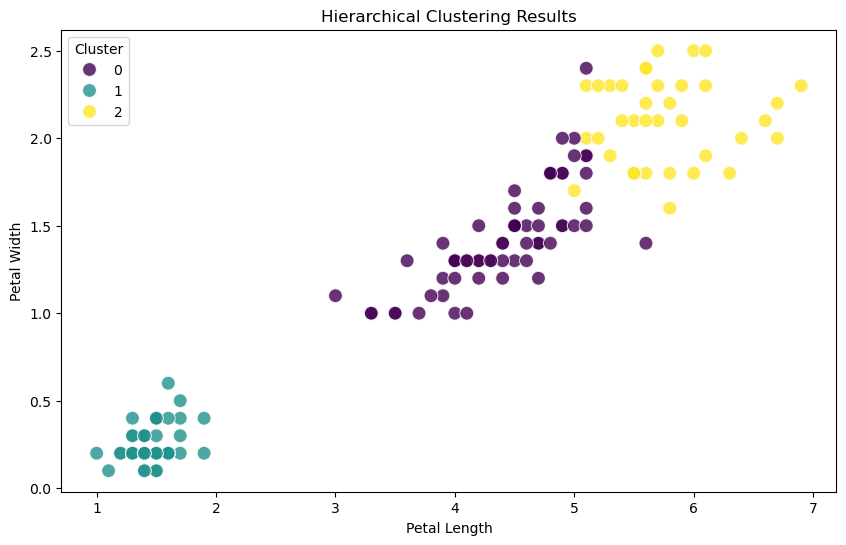

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data.iloc[:, 2], y=data.iloc[:, 3], hue=y_hc, 
                palette='viridis', s=100, alpha=0.8)
plt.title('Hierarchical Clustering Results')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Cluster')
plt.show()

In [22]:
print(y_hc[:5])

[1 1 1 1 1]
